In [1]:
from google.colab import drive
import os

# Mount Google Drive
drive.mount('/content/drive')

# Set up Kaggle API credentials
os.makedirs('/root/.kaggle', exist_ok=True)
!cp /content/drive/MyDrive/kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

# Download and unzip the dataset
!kaggle datasets download -d ejlok1/toronto-emotional-speech-set-tess -p /content/drive/MyDrive/dataset --unzip


Mounted at /content/drive
Dataset URL: https://www.kaggle.com/datasets/ejlok1/toronto-emotional-speech-set-tess
License(s): Attribution-NonCommercial-NoDerivatives 4.0 International (CC BY-NC-ND 4.0)
100% 427M/428M [00:17<00:00, 23.5MB/s]
100% 428M/428M [00:17<00:00, 25.4MB/s]


In [12]:
import os

# Define dataset path
dataset_path = "/content/drive/MyDrive/dataset/TESS Toronto emotional speech set data"

# List folders in the dataset directory and standardize names
emotion_folders = sorted(os.listdir(dataset_path))
print("Emotion Folders:", emotion_folders)


Emotion Folders: ['OAF_Fear', 'OAF_Pleasant_surprise', 'OAF_Sad', 'OAF_angry', 'OAF_disgust', 'OAF_happy', 'OAF_neutral', 'YAF_angry', 'YAF_disgust', 'YAF_fear', 'YAF_happy', 'YAF_neutral', 'YAF_pleasant_surprised', 'YAF_sad']


In [13]:
from collections import defaultdict

# Normalize folder names by converting to lowercase
folder_name_mapping = {folder.lower(): folder for folder in emotion_folders}

# Standardized emotion names
emotion_counts = defaultdict(int)
total_files = 0

for folder_lower, folder_original in folder_name_mapping.items():
    folder_path = os.path.join(dataset_path, folder_original)
    if os.path.isdir(folder_path):  # Ensure it's a folder
        num_files = len(os.listdir(folder_path))
        emotion_counts[folder_lower] = num_files
        total_files += num_files

# Display counts
for emotion, count in emotion_counts.items():
    print(f"{emotion}: {count} files")

print(f"\nTotal number of audio files: {total_files}")


oaf_fear: 200 files
oaf_pleasant_surprise: 200 files
oaf_sad: 200 files
oaf_angry: 200 files
oaf_disgust: 200 files
oaf_happy: 200 files
oaf_neutral: 200 files
yaf_angry: 200 files
yaf_disgust: 200 files
yaf_fear: 200 files
yaf_happy: 200 files
yaf_neutral: 200 files
yaf_pleasant_surprised: 200 files
yaf_sad: 200 files

Total number of audio files: 2800


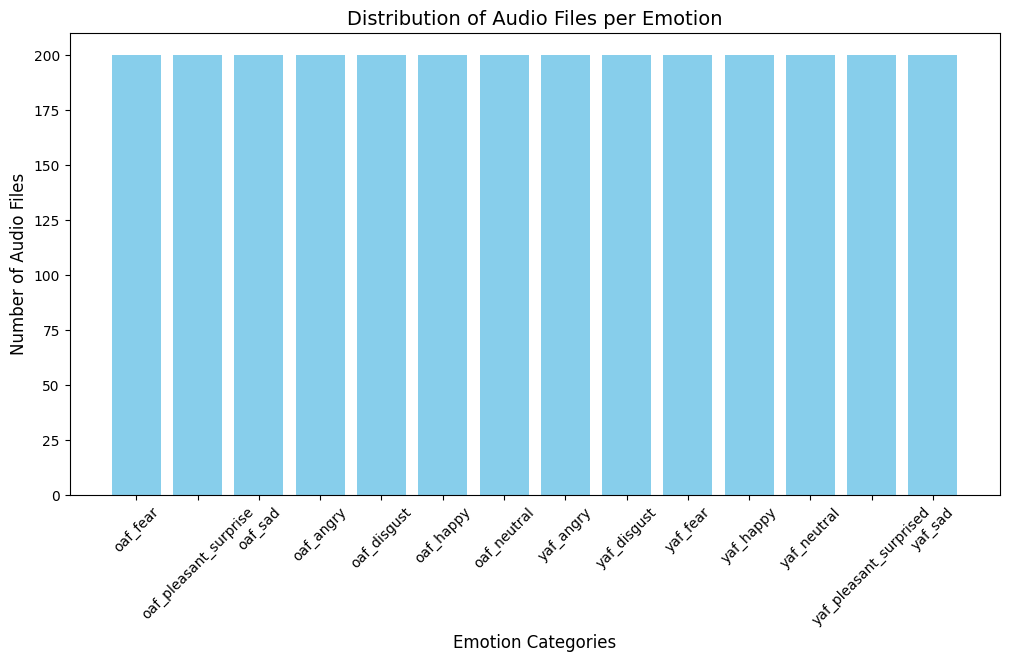

In [14]:
import matplotlib.pyplot as plt

# Plot the number of files per emotion
plt.figure(figsize=(12, 6))
plt.bar(emotion_counts.keys(), emotion_counts.values(), color='skyblue')
plt.xlabel("Emotion Categories", fontsize=12)
plt.ylabel("Number of Audio Files", fontsize=12)
plt.title("Distribution of Audio Files per Emotion", fontsize=14)
plt.xticks(rotation=45)
plt.show()


Audio File Counts per Emotion Type:
fear: 400 files
pleasant_surprise: 400 files
sad: 400 files
angry: 400 files
disgust: 400 files
happy: 400 files
neutral: 400 files


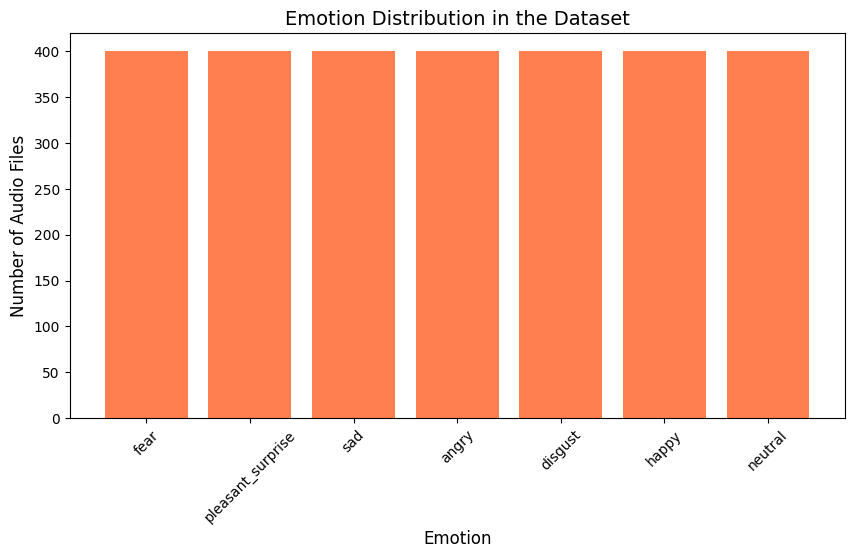

In [15]:
from collections import Counter
import matplotlib.pyplot as plt

# Normalize and clean emotion names from folder names
emotion_labels = []
for folder in emotion_counts.keys():
    parts = folder.lower().split("_")  # Convert to lowercase for uniformity
    emotion = "_".join(parts[1:])  # Extract emotion name

    # Standardize "pleasant_surprise" variations
    if emotion in ["pleasant_surprise", "pleasant_surprised"]:
        emotion = "pleasant_surprise"

    emotion_labels.append(emotion)

# Count occurrences of each emotion
emotion_data = Counter()
for folder, count in emotion_counts.items():
    parts = folder.lower().split("_")
    emotion = "_".join(parts[1:])

    # Standardize "pleasant_surprise" variations
    if emotion in ["pleasant_surprise", "pleasant_surprised"]:
        emotion = "pleasant_surprise"

    emotion_data[emotion] += count

# Display counts
print("Audio File Counts per Emotion Type:")
for emotion, count in emotion_data.items():
    print(f"{emotion}: {count} files")

# Plot the emotion distribution
plt.figure(figsize=(10, 5))
plt.bar(emotion_data.keys(), emotion_data.values(), color='coral')
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Audio Files", fontsize=12)
plt.title("Emotion Distribution in the Dataset", fontsize=14)
plt.xticks(rotation=45)
plt.show()



Merged Category Distribution:
Depression: 800 files
Anxiety: 400 files
Normal: 1600 files


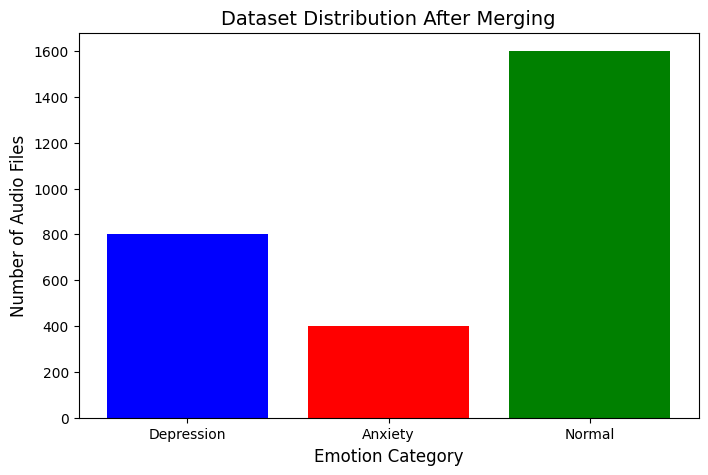

In [16]:
# Define case-insensitive emotion-to-category mapping
emotion_to_category = {
    "sad": "Depression",
    "disgust": "Depression",
    "fear": "Anxiety",
    "neutral": "Normal",
    "happy": "Normal",
    "angry": "Normal",
    "pleasant_surprise": "Normal",
    "pleasant_surprised": "Normal"  # Handling different folder variations
}

# Initialize category counts
category_counts = {"Depression": 0, "Anxiety": 0, "Normal": 0}

# Process each folder
for folder_lower, count in emotion_counts.items():
    # Extract standardized emotion name
    parts = folder_lower.split("_")
    emotion = "_".join(parts[1:])  # Extract everything after "OAF_" or "YAF_"

    # Handle variations in "pleasant_surprise"
    if emotion in ["pleasant_surprise", "pleasant_surprised"]:
        emotion = "pleasant_surprise"

    # Map emotion to category
    category = emotion_to_category.get(emotion, None)
    if category:
        category_counts[category] += count

# Display merged category counts
print("\nMerged Category Distribution:")
for category, count in category_counts.items():
    print(f"{category}: {count} files")

# Plot merged category distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(category_counts.keys(), category_counts.values(), color=['blue', 'red', 'green'])
plt.xlabel("Emotion Category", fontsize=12)
plt.ylabel("Number of Audio Files", fontsize=12)
plt.title("Dataset Distribution After Merging", fontsize=14)
plt.show()


In [19]:
import shutil
import os

# Define dataset paths
original_dataset_path = "/content/drive/MyDrive/dataset/TESS Toronto emotional speech set data"
merged_dataset_path = "/content/drive/MyDrive/dataset/TESS_Merged"

# Ensure the merged dataset directory exists
os.makedirs(merged_dataset_path, exist_ok=True)

# Define category folder paths
category_paths = {
    "Depression": os.path.join(merged_dataset_path, "Depression"),
    "Anxiety": os.path.join(merged_dataset_path, "Anxiety"),
    "Normal": os.path.join(merged_dataset_path, "Normal")
}

# Create subfolders for each category
for path in category_paths.values():
    os.makedirs(path, exist_ok=True)

# Define folder-to-category mapping
folder_to_category = {
    "OAF_Sad": "Depression", "YAF_sad": "Depression",
    "OAF_disgust": "Depression", "YAF_disgust": "Depression",
    "OAF_Fear": "Anxiety", "YAF_fear": "Anxiety",
    "OAF_neutral": "Normal", "YAF_neutral": "Normal",
    "OAF_happy": "Normal", "YAF_happy": "Normal",
    "OAF_angry": "Normal", "YAF_angry": "Normal",
    "OAF_Pleasant_surprise": "Normal", "YAF_pleasant_surprised": "Normal"
}

# Copy files to the correct categories
for folder, category in folder_to_category.items():
    folder_path = os.path.join(original_dataset_path, folder)

    # Ensure the folder exists before processing
    if os.path.exists(folder_path):
        for file in os.listdir(folder_path):
            src_file = os.path.join(folder_path, file)
            dest_file = os.path.join(category_paths[category], file)
            shutil.copy(src_file, dest_file)

print("✅ Merged dataset has been successfully saved in Google Drive at:", merged_dataset_path)


✅ Merged dataset has been successfully saved in Google Drive at: /content/drive/MyDrive/dataset/TESS_Merged


In [20]:
import random
import IPython.display as ipd

# Function to get a random audio file from a category
def get_random_audio(category):
    category_path = os.path.join(merged_dataset_path, category)
    files = os.listdir(category_path)
    if files:
        return os.path.join(category_path, random.choice(files))
    return None

# Get random audio files
sample_files = {
    "Depression": get_random_audio("Depression"),
    "Anxiety": get_random_audio("Anxiety"),
    "Normal": get_random_audio("Normal")
}

# Display audio files
for category, file_path in sample_files.items():
    if file_path:
        print(f"🔊 Playing sample from {category}: {os.path.basename(file_path)}")
        display(ipd.Audio(file_path))


🔊 Playing sample from Depression: YAF_shall_sad.wav


🔊 Playing sample from Anxiety: OAF_love_fear.wav


🔊 Playing sample from Normal: YAF_fail_ps.wav


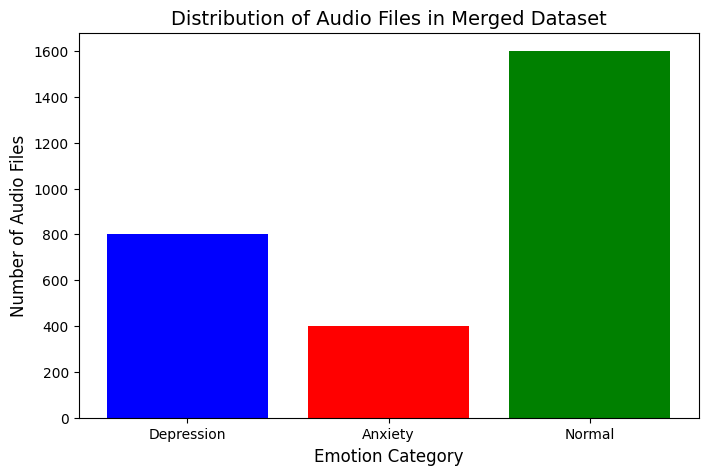

📊 Audio File Counts per Category:
Depression: 800 files
Anxiety: 400 files
Normal: 1600 files


In [21]:
import matplotlib.pyplot as plt

# Count files in each category
category_counts = {category: len(os.listdir(path)) for category, path in category_paths.items()}

# Plot the distribution
plt.figure(figsize=(8, 5))
plt.bar(category_counts.keys(), category_counts.values(), color=['blue', 'red', 'green'])
plt.xlabel("Emotion Category", fontsize=12)
plt.ylabel("Number of Audio Files", fontsize=12)
plt.title("Distribution of Audio Files in Merged Dataset", fontsize=14)
plt.show()

# Display count values
print("📊 Audio File Counts per Category:")
for category, count in category_counts.items():
    print(f"{category}: {count} files")


🔊 Visualizing Depression - OAF_rush_sad.wav


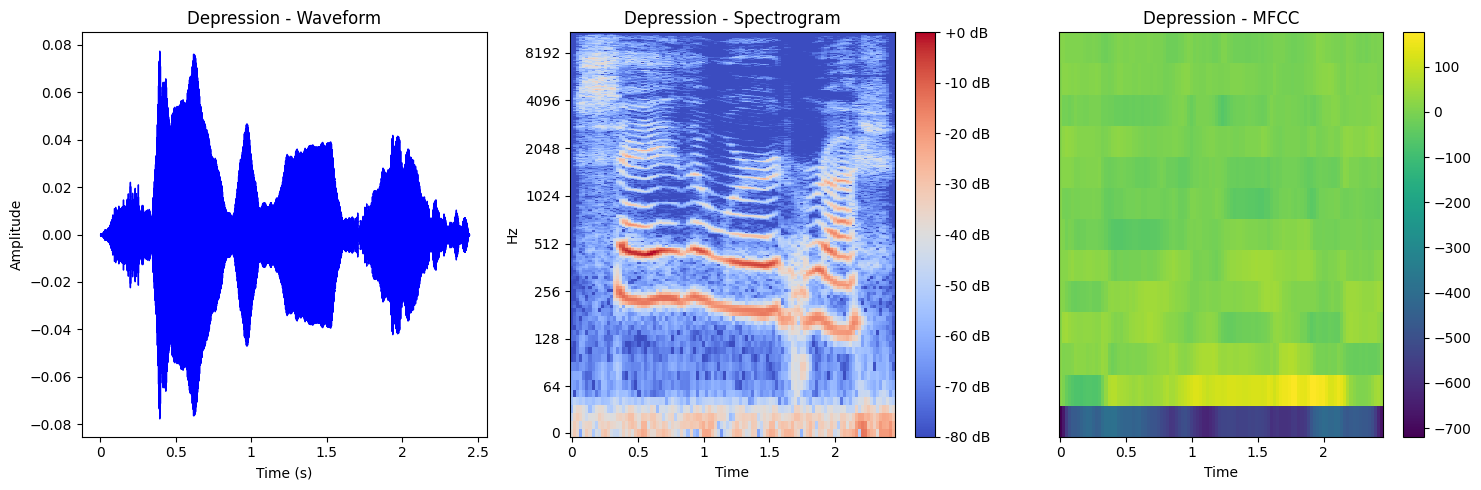

🔊 Visualizing Anxiety - YAF_dip_fear.wav


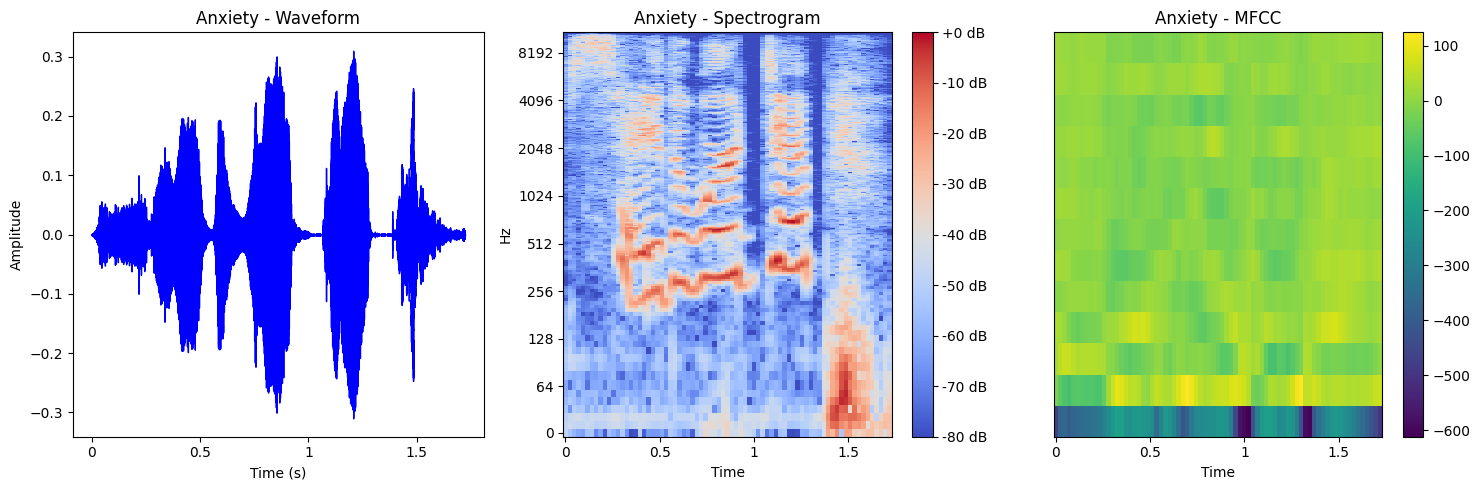

🔊 Visualizing Normal - OAF_seize_ps.wav


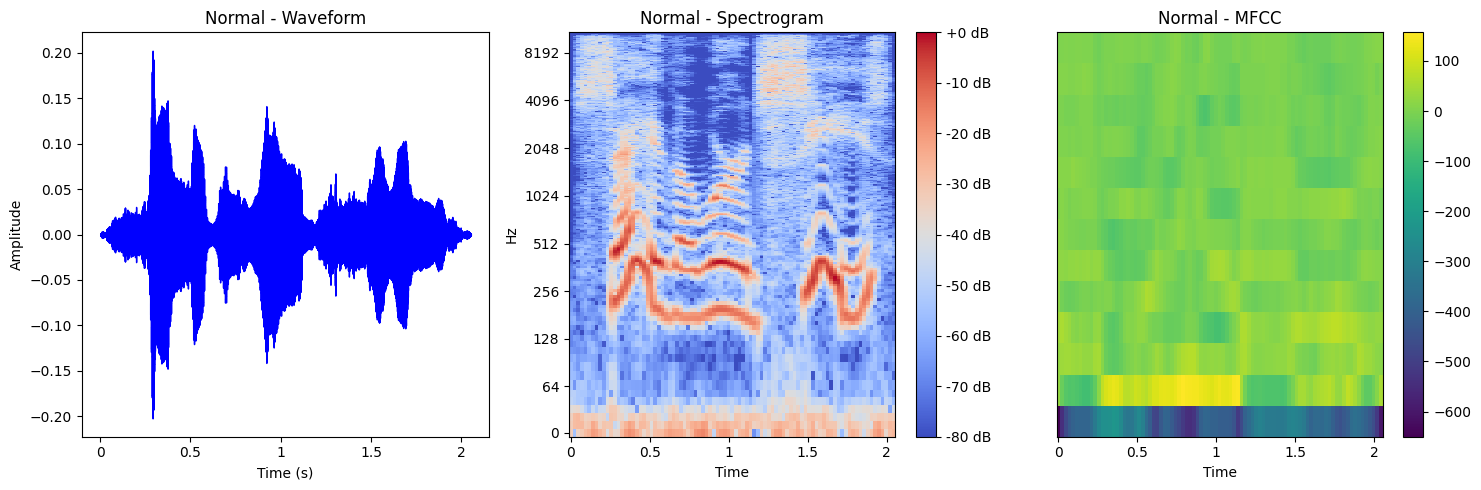

In [22]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt
import random

# Select a random file from each category
def get_random_file(category):
    category_path = os.path.join(merged_dataset_path, category)
    files = os.listdir(category_path)
    if files:
        return os.path.join(category_path, random.choice(files))
    return None

# Select sample audio files
sample_audio_paths = {
    "Depression": get_random_file("Depression"),
    "Anxiety": get_random_file("Anxiety"),
    "Normal": get_random_file("Normal")
}

# Function to visualize audio features
def plot_audio_features(file_path, title):
    if not file_path:
        print(f"No file found for {title}")
        return

    # Load audio file
    y, sr = librosa.load(file_path)

    # Plot waveform
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    librosa.display.waveshow(y, sr=sr, color='blue')
    plt.title(f"{title} - Waveform")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")

    # Plot spectrogram
    plt.subplot(1, 3, 2)
    S = librosa.stft(y)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)
    librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='log', cmap='coolwarm')
    plt.title(f"{title} - Spectrogram")
    plt.colorbar(format='%+2.0f dB')

    # Plot MFCCs
    plt.subplot(1, 3, 3)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    librosa.display.specshow(mfccs, x_axis='time', cmap='viridis')
    plt.colorbar()
    plt.title(f"{title} - MFCC")

    plt.tight_layout()
    plt.show()

# Generate plots for each emotion category
for category, file_path in sample_audio_paths.items():
    print(f"🔊 Visualizing {category} - {os.path.basename(file_path)}")
    plot_audio_features(file_path, category)


In [24]:
import librosa
import numpy as np
import pandas as pd

# Function to extract audio features
def extract_features(file_path):
    y, sr = librosa.load(file_path)  # Load the audio file

    # Compute features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    # Compute mean values for each feature
    mfccs_mean = np.mean(mfccs, axis=1)
    chroma_mean = np.mean(chroma, axis=1)
    spectral_contrast_mean = np.mean(spectral_contrast, axis=1)

    # Pad shorter arrays with NaN to match the longest array
    max_length = max(len(mfccs_mean), len(chroma_mean), len(spectral_contrast_mean))

    mfccs_mean = np.pad(mfccs_mean, (0, max_length - len(mfccs_mean)), constant_values=np.nan)
    chroma_mean = np.pad(chroma_mean, (0, max_length - len(chroma_mean)), constant_values=np.nan)
    spectral_contrast_mean = np.pad(spectral_contrast_mean, (0, max_length - len(spectral_contrast_mean)), constant_values=np.nan)

    return mfccs_mean, chroma_mean, spectral_contrast_mean

# Extract features for each category
feature_data = {}

for category, file_path in sample_audio_paths.items():
    if file_path:
        mfccs, chroma, spectral_contrast = extract_features(file_path)

        # Convert to DataFrame
        df_features = pd.DataFrame({
            "MFCCs": mfccs,
            "Chroma": chroma,
            "Spectral Contrast": spectral_contrast
        })

        # Store data
        feature_data[category] = df_features

# Display extracted feature values
for category, df in feature_data.items():
    print(f"\n📌 Extracted Features for {category}: {os.path.basename(sample_audio_paths[category])}")
    print(df)



📌 Extracted Features for Depression: OAF_rush_sad.wav
         MFCCs    Chroma  Spectral Contrast
0  -507.616333  0.172246          24.372614
1    74.925552  0.177460          23.055039
2    19.538740  0.215510          26.466495
3    10.677264  0.248373          21.645596
4    16.973640  0.274494          22.164126
5    15.135050  0.338131          19.295030
6   -12.850651  0.277818          50.991288
7   -19.125290  0.302463                NaN
8   -15.473278  0.261708                NaN
9     4.477414  0.363186                NaN
10  -11.648610  0.452650                NaN
11    2.525152  0.271624                NaN
12   -5.670700       NaN                NaN

📌 Extracted Features for Anxiety: YAF_dip_fear.wav
         MFCCs    Chroma  Spectral Contrast
0  -317.346100  0.396573          15.166149
1    29.862715  0.415464          20.508762
2   -13.448936  0.441865          20.837448
3    16.093330  0.425146          18.115901
4     1.837167  0.350482          18.970005
5    -3.80903

In [25]:
import os
import librosa
import numpy as np
import pandas as pd

# Define dataset path
dataset_path = "/content/drive/MyDrive/dataset/TESS Toronto emotional speech set data"

# Function to extract audio features
def extract_features(file_path):
    y, sr = librosa.load(file_path)  # Load audio file

    # Extract features
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)

    # Compute mean values
    mfccs_mean = np.mean(mfccs, axis=1)
    chroma_mean = np.mean(chroma, axis=1)
    spectral_contrast_mean = np.mean(spectral_contrast, axis=1)

    # Combine into a single feature array
    features = np.concatenate((mfccs_mean, chroma_mean, spectral_contrast_mean))

    return features

# Prepare dataset storage
data = []

# Loop through each category and extract features
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):  # Ensure it's a folder
        label = None

        # Assign categories based on folder names
        if folder in ["OAF_Sad", "OAF_disgust", "YAF_sad", "YAF_disgust"]:
            label = "Depression"
        elif folder in ["OAF_Fear", "YAF_fear"]:
            label = "Anxiety"
        elif folder in ["OAF_angry", "OAF_happy", "OAF_neutral", "OAF_Pleasant_surprise",
                        "YAF_angry", "YAF_happy", "YAF_neutral", "YAF_pleasant_surprised"]:
            label = "Normal"

        # Process each audio file
        if label:
            for file in os.listdir(folder_path):
                file_path = os.path.join(folder_path, file)

                # Extract features
                try:
                    features = extract_features(file_path)
                    data.append([file, label] + list(features))
                except Exception as e:
                    print(f"Error processing {file}: {e}")

# Convert data to a DataFrame
columns = ["Filename", "Emotion"] + [f"Feature_{i}" for i in range(len(data[0]) - 2)]
df = pd.DataFrame(data, columns=columns)

# Save to CSV file
csv_path = "/content/drive/MyDrive/dataset/TESS_audio_features.csv"
df.to_csv(csv_path, index=False)

print(f"✅ Feature extraction completed! Dataset saved at: {csv_path}")

# Display sample rows
df.head()


✅ Feature extraction completed! Dataset saved at: /content/drive/MyDrive/dataset/TESS_audio_features.csv


,Filename,Emotion,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Feature_7,...,Feature_22,Feature_23,Feature_24,Feature_25,Feature_26,Feature_27,Feature_28,Feature_29,Feature_30,Feature_31
0,OAF_back_fear.wav,Anxiety,-434.416840,61.591835,1.869825,-8.288072,2.913275,3.220161,-13.606009,-0.346508,...,0.273205,0.324255,0.318041,22.794704,23.213973,22.891643,20.558654,21.470778,18.120759,47.596309
1,OAF_bar_fear.wav,Anxiety,-433.824646,70.088837,12.938360,-21.756363,-6.834160,4.844457,-11.890791,-0.407226,...,0.253846,0.249001,0.219839,23.353286,26.443642,25.250553,24.431355,23.146356,19.086337,49.779701
2,OAF_base_fear.wav,Anxiety,-443.532318,38.710720,11.385891,5.367714,8.344028,0.096640,-12.813403,-2.515016,...,0.243166,0.244979,0.269832,23.348135,23.821711,22.571743,21.466647,21.368319,19.181027,48.128395
3,OAF_bath_fear.wav,Anxiety,-405.627777,61.299316,7.477961,-13.963837,-1.340553,2.632162,-11.384148,-0.700052,...,0.269471,0.324412,0.337801,22.005249,22.642810,22.914293,20.868673,21.807456,18.942595,47.906213
4,OAF_bean_fear.wav,Anxiety,-491.337769,53.490482,20.951565,8.448865,8.880781,0.637741,-6.358855,1.899915,...,0.178721,0.258132,0.348966,23.815119,24.274177,23.111718,21.260854,21.147717,19.359906,47.490657


Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Filename    2800 non-null   object 
 1   Emotion     2800 non-null   object 
 2   Feature_0   2800 non-null   float64
 3   Feature_1   2800 non-null   float64
 4   Feature_2   2800 non-null   float64
 5   Feature_3   2800 non-null   float64
 6   Feature_4   2800 non-null   float64
 7   Feature_5   2800 non-null   float64
 8   Feature_6   2800 non-null   float64
 9   Feature_7   2800 non-null   float64
 10  Feature_8   2800 non-null   float64
 11  Feature_9   2800 non-null   float64
 12  Feature_10  2800 non-null   float64
 13  Feature_11  2800 non-null   float64
 14  Feature_12  2800 non-null   float64
 15  Feature_13  2800 non-null   float64
 16  Feature_14  2800 non-null   float64
 17  Feature_15  2800 non-null   float64
 18  Feature_16  2800 non-null   float64
 19  Feature_1

<ipython-input-26-dd372495bb44>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="coolwarm")


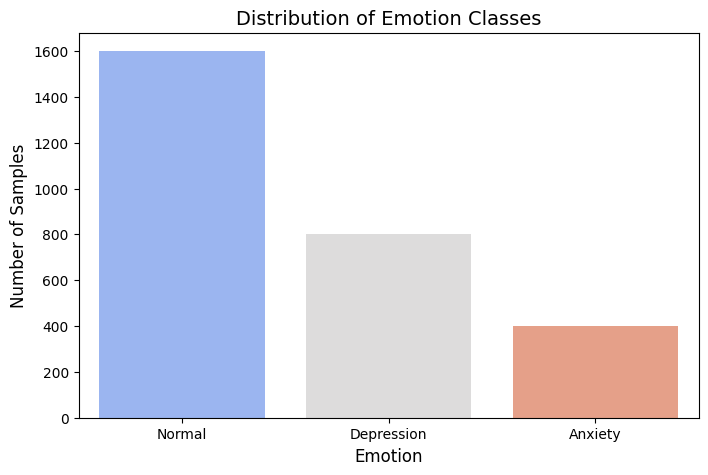

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
csv_path = "/content/drive/MyDrive/dataset/TESS_audio_features.csv"
df = pd.read_csv(csv_path)

# Display dataset info
print("Dataset Overview:")
print(df.info())

# Count the number of samples per emotion category
emotion_counts = df["Emotion"].value_counts()
print("\nSample Counts per Emotion:\n", emotion_counts)

# Plot the distribution of emotions
plt.figure(figsize=(8, 5))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="coolwarm")
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Number of Samples", fontsize=12)
plt.title("Distribution of Emotion Classes", fontsize=14)
plt.show()


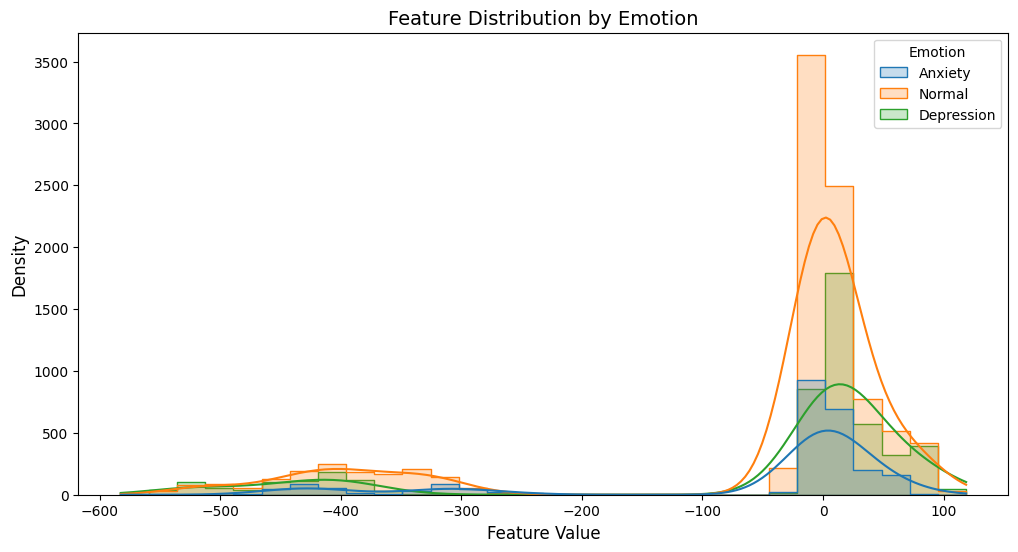

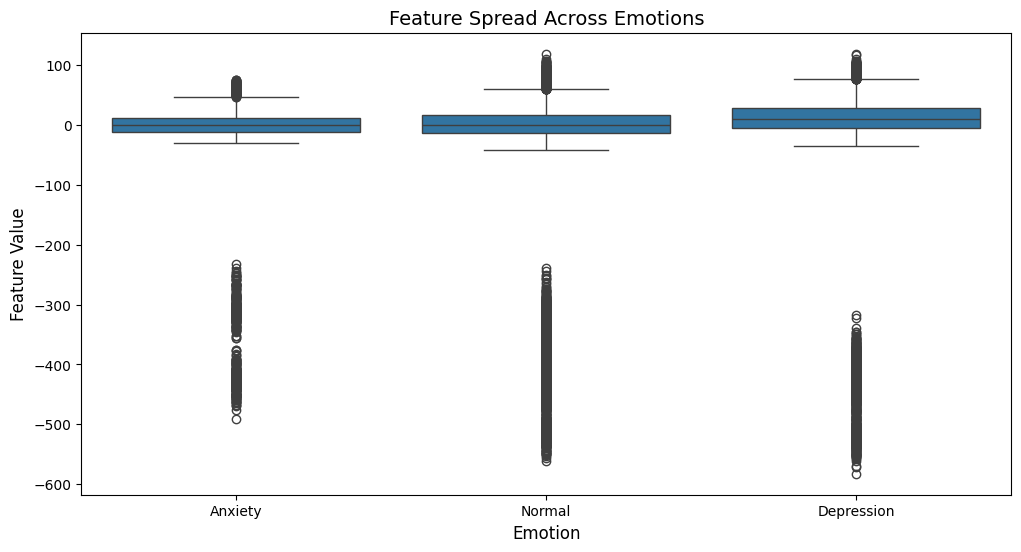

In [27]:
# Select numerical feature columns
feature_columns = df.columns[2:]

# Plot histograms for a few features
df_melted = df.melt(id_vars=["Emotion"], value_vars=feature_columns[:6])  # First 6 features
plt.figure(figsize=(12, 6))
sns.histplot(data=df_melted, x="value", hue="Emotion", element="step", kde=True, bins=30)
plt.xlabel("Feature Value", fontsize=12)
plt.ylabel("Density", fontsize=12)
plt.title("Feature Distribution by Emotion", fontsize=14)
plt.show()

# Boxplot to check feature spread
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_melted, x="Emotion", y="value")
plt.xlabel("Emotion", fontsize=12)
plt.ylabel("Feature Value", fontsize=12)
plt.title("Feature Spread Across Emotions", fontsize=14)
plt.show()
